<hr style='height:4px; background-color:black; border:none; margin-top:20px; margin-bottom:20px;'>

# **Name:** Tim Hollis  
# **Course:** DSC540 - Data Preparation  
# **Date:**  02/01/2026
# **Assignment:** Week 5 & 6 Exercises 



<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **Week 5 & 6 – Assignment Overview**

**Purpose**  
The focus for the assignment this week is on different aspects of data acquisition, cleaning, and storage. The work is divided into three main actiities, each with its own explanation, code, and summary.
 
- **Activity 5.01**: Web scraping GDP data from Wikipedia using BeautifulSoup  
- **Activity 6.01**: Cleaning and analyzing the `visit_data.csv` dataset, including outlier detection  
- **SQLite Data Task**: Creating a SQLite database, defining a table, inserting records, and querying results  

**Datasets and Sources**  
- **GDP (Nominal) Table** — Scraped from the Wikipedia page: https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal) 
- `visit_data.csv` provided in the course materials and stored locally in the same directory as this notebook  

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## Initial Setup

In [1]:
# Import Needed Libraries
from bs4 import BeautifulSoup
from IPython.display import Markdown, HTML, display
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import sqlite3

# Pandas formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Load dataset
visit_data = pd.read_csv('visit_data.csv')

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **Activity 5.01 – Web Scraping GDP Data**

**Steps to Complete**  
1. Open and inspect the following Wikipedia page structure: https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)
2. Read the page content using `BeautifulSoup`
3. Identify how many tables are present and locate the correct GDP table
4. Extract the three source names from the table header
5. Separate the header and row data
6. Create three DataFrames, one for each GDP source  

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

In [2]:
# Step 1: Completed

# Step 2: Read the page content using BeautifulSoup
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# Step 3: Identify how many tables are present and locate the correct GDP table
tables = soup.find_all('table', {'class': 'wikitable'})

gdp_table = tables[0]

# Step 4: Extract the three source names from the table header
header_row = gdp_table.find_all('tr')[0]
header_cells = header_row.find_all(['th', 'td'])
source_names = [cell.get_text(strip=True) for cell in header_cells][1:]

# Step 5: Separate the header and row data
rows = gdp_table.find_all('tr')[1:]
data_rows = []

for row in rows:
    cells = row.find_all(['td', 'th'])
    cell_text = [cell.get_text(strip=True) for cell in cells]
    if len(cell_text) >= 4:
        data_rows.append(cell_text)

# Step 6: Create a dataframe for each source
countries = [row[0] for row in data_rows]

df_source1 = pd.DataFrame({
    'Country': countries,
    source_names[0]: [row[1] for row in data_rows]
})

df_source2 = pd.DataFrame({
    'Country': countries,
    source_names[1]: [row[2] for row in data_rows]
})

df_source3 = pd.DataFrame({
    'Country': countries,
    source_names[2]: [row[3] for row in data_rows]
})

print(f'✓ Webpage inspection: Complete')
print(f'Number of wikitable tables found: {len(tables)}')

# Display tables
display(df_source1.head())
display(df_source2.head())
display(df_source3.head())

✓ Webpage inspection: Complete
Number of wikitable tables found: 1


,Country,IMF(2025)[6]
0,World,"117,165,394"
1,United States,"30,615,743"
2,China[n 1],"19,398,577"
3,Germany,"5,013,574"
4,Japan,"4,279,828"


,Country,World Bank(2024)[7]
0,World,"111,326,370"
1,United States,"28,750,956"
2,China[n 1],"18,743,803"
3,Germany,"4,685,593"
4,Japan,"4,027,598"


,Country,United Nations(2023)[8]
0,World,"100,834,796"
1,United States,"27,720,700"
2,China[n 1],"17,794,782"
3,Germany,"4,525,704"
4,Japan,"4,204,495"


<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **Summary**

This activity focused on extracting GDP (nominal) data from a structured Wikipedia table using `requests` and `BeautifulSoup`. After inspecting the page structure, the correct `wikitable` was identified and parsed into usable components.

**Key Steps Completed**  
- Retrieved the HTML content using a browser-style User-Agent  
- Located the single GDP table on the page  
- Extracted the three GDP source names from the header row  
- Parsed all row data into structured lists  
- Created three separate DataFrames, one for each GDP source:  
  - *IMF (2025)*  
  - *World Bank (2024)*  
  - *United Nations (2023)*  

**Result**  
The final output consists of three DataFrames containing country-level GDP values from each source. 


<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **Activity 6.01 – Outlier Detection & Data Cleaning**

**Steps to Complete**  
1. Load the `visit_data.csv` dataset into a DataFrame (already loaded in initial setup) 
2. Check for duplicate rows and remove them if present  
3. Inspect the dataset for missing values across all columns  
4. Identify outliers in the `visit` column using the IQR method  
5. Create a box plot to visualize the distribution and detect outliers  
6. Remove outliers based on the calculated IQR bounds  
7. Compare the original dataset size to the cleaned dataset size  

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

Duplicate rows found: 0

Missing values per column:
id              0
first_name    296
last_name     296
email           0
gender        505
ip_address      0
visit          26
dtype: int64

Lower outlier threshold: -1350.125
Upper outlier threshold: 4368.875


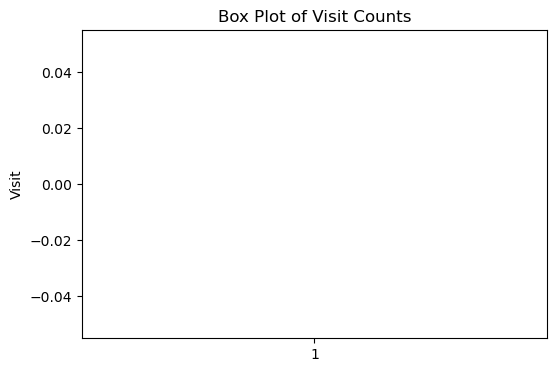


Original dataset size: 1000
Cleaned dataset size: 974
Removed rows: 26


,id,first_name,last_name,email,gender,ip_address,visit
0,1,Sonny,Dahl,sdahl0@mysql.com,Male,135.36.96.183,"1,225.00"
1,2,NaN,NaN,dhoovart1@hud.gov,NaN,237.165.194.143,919.00
2,3,Gar,Armal,garmal2@technorati.com,NaN,166.43.137.224,271.00
3,4,Chiarra,Nulty,cnulty3@newyorker.com,NaN,139.98.137.108,"1,002.00"
4,5,NaN,NaN,sleaver4@elegantthemes.com,NaN,46.117.117.27,"2,434.00"


In [3]:
# Step 1: Load the dataset
visits = visit_data.copy()

# Step 2: Check for duplicates
duplicate_count = visits.duplicated().sum()
print(f'Duplicate rows found: {duplicate_count}')

# Remove duplicates
visits = visits.drop_duplicates()

# Step 3: Check for missing values
missing_values = visits.isna().sum()
print('\nMissing values per column:')
print(missing_values)

# Step 4: Identify outliers in the "visit" column using the IQR method
q1 = visits['visit'].quantile(0.25)
q3 = visits['visit'].quantile(0.75)
iqr = q3 - q1

lower_outlier = q1 - 1.5 * iqr
upper_outlier = q3 + 1.5 * iqr

print(f'\nLower outlier threshold: {lower_outlier}')
print(f'Upper outlier threshold: {upper_outlier}')

# Step 5: Create a box plot to visualize outliers
plt.figure(figsize=(6, 4))
plt.boxplot(visits['visit'])
plt.title('Box Plot of Visit Counts')
plt.ylabel('Visit')
plt.show()

# Step 6: Remove outliers
cleaned_visits = visits[(visits['visit'] >= lower_outlier)
                        & (visits['visit'] <= upper_outlier)]

# Step 7: Report size difference
original_size = len(visit_data)
cleaned_size = len(cleaned_visits)

print(f'\nOriginal dataset size: {original_size}')
print(f'Cleaned dataset size: {cleaned_size}')
print(f'Removed rows: {original_size - cleaned_size}')

# Display the first few rows of the cleaned dataset
display(cleaned_visits.head())

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **Activity 6.01 Summary**

**Overview**  
This activity focused on evaluating the `visit_data.csv` dataset for data quality issues and identifying potential outliers using the IQR method. The steps included checking for duplicates, assessing missing values, visualizing the distribution of visit counts, and determining whether any values fell outside the calculated outlier thresholds.

**Key Steps Completed**  
- Loaded the dataset and created a working copy for cleaning  
- Identified and removed duplicate rows  
- Checked all columns for missing values  
- Calculated the first quartile, third quartile, and IQR for the `visit` column  
- Computed lower and upper outlier thresholds using the standard 1.5 × IQR rule  
- Visualized the distribution of visit counts using a box plot  
- Compared the original dataset size to the cleaned dataset size after applying the outlier filter  

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **SQLite Data Task – Database Creation & Querying**

**Steps to Complete**  
1. Create a new SQLite database file using the `sqlite3` library  
2. Establish a connection and create a cursor object  
3. Define a table structure with appropriate column names and data types  
4. Insert multiple records into the table  
5. Commit the changes to save the inserted data  
6. Write and execute a SQL query to retrieve selected fields  
7. Load the query results into a pandas DataFrame for display  

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

In [4]:
# Step 1: Create a new SQLite database file
connection = sqlite3.connect('customer_data.db')

# Step 2: Establish a connection and create a cursor object
cursor = connection.cursor()

# Step 3: Drop and recreate the table
cursor.execute('DROP TABLE IF EXISTS customers')

cursor.execute('''
    CREATE TABLE customers (
        id INTEGER PRIMARY KEY,
        name TEXT,
        address TEXT,
        city TEXT,
        state TEXT,
        zip TEXT,
        phone TEXT
    )
''')

# Step 4: Insert at least 10 rows of data
records = [
    (1, 'Alice Johnson', '123 Maple St', 'Austin', 'TX', '73301', '512-555-0198'),
    (2, 'Brian Smith', '44 Oak Ridge Ln', 'Dallas', 'TX', '75001', '214-555-4421'),
    (3, 'Carla Martinez', '890 Pine Ave', 'Houston', 'TX', '77001', '713-555-8820'),
    (4, 'David Lee', '77 Sunset Blvd', 'San Antonio', 'TX', '78201', '210-555-3344'),
    (5, 'Emily Davis', '501 River Rd', 'El Paso', 'TX', '79901', '915-555-7712'),
    (6, 'Frank Wilson', '12 Canyon Dr', 'Fort Worth', 'TX', '76101', '817-555-9921'),
    (7, 'Grace Thompson', '300 Hillcrest Ct',
     'Plano', 'TX', '75023', '469-555-1100'),
    (8, 'Henry Clark', '88 Cedar Way', 'Lubbock', 'TX', '79401', '806-555-6734'),
    (9, 'Isabella Lopez', '210 Lakeview Rd',
     'Waco', 'TX', '76701', '254-555-9087'),
    (10, 'James Walker', '640 Meadow Ln', 'Amarillo', 'TX', '79101', '806-555-4429')
]

cursor.executemany(
    'INSERT INTO customers VALUES (?, ?, ?, ?, ?, ?, ?)',
    records)

# Step 5: Commit the changes
connection.commit()

# Step 6: Query the required fields
cursor.execute('SELECT name, address, city, state, zip, phone FROM customers')
query_results = cursor.fetchall()

# Step 7: Load results into a DataFrame
df_results = pd.DataFrame(
    query_results,
    columns=['name', 'address', 'city', 'state', 'zip', 'phone']
)

display(df_results)

# Close the connection
connection.close()

,name,address,city,state,zip,phone
0,Alice Johnson,123 Maple St,Austin,TX,73301,512-555-0198
1,Brian Smith,44 Oak Ridge Ln,Dallas,TX,75001,214-555-4421
2,Carla Martinez,890 Pine Ave,Houston,TX,77001,713-555-8820
3,David Lee,77 Sunset Blvd,San Antonio,TX,78201,210-555-3344
4,Emily Davis,501 River Rd,El Paso,TX,79901,915-555-7712
5,Frank Wilson,12 Canyon Dr,Fort Worth,TX,76101,817-555-9921
6,Grace Thompson,300 Hillcrest Ct,Plano,TX,75023,469-555-1100
7,Henry Clark,88 Cedar Way,Lubbock,TX,79401,806-555-6734
8,Isabella Lopez,210 Lakeview Rd,Waco,TX,76701,254-555-9087
9,James Walker,640 Meadow Ln,Amarillo,TX,79101,806-555-4429


<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **SQLite Data Task Summary**

**Overview**  
This exercise demonstrated how to create and interact with a lightweight relational database using SQLite. The task involved defining a table schema, inserting multiple records, and retrieving selected fields through a SQL query. The workflow reinforced the connection between Python and SQL, showing how structured data can be stored, queried, and displayed within a pandas DataFrame.

**Key Steps Completed**  
- Created a new SQLite database file and established a connection  
- Defined a table with the required fields: Name, Address, City, State, Zip, and Phone Number  
- Inserted at least ten rows of custom data into the table  
- Executed a SQL query to retrieve selected fields from the database  
- Loaded the query results into a pandas DataFrame for display and verification  

**Result**  
The database was successfully created, populated, and queried. The final DataFrame confirmed that all inserted records were stored correctly and that the SQL query returned the expected fields. This exercise provided practical experience with database creation, data insertion, and SQL querying within a Python workflow.

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **Reflection on the Assignment**

### **Overall Assessment**
This assignment provided a broad, hands-on review of essential data analysis skills, including web scraping, data cleaning, visualization, and SQL database operations. Working through each activity reinforced the importance of reproducible workflows, clear documentation, and methodical troubleshooting. The structure of the tasks made it easy to see how different tools and techniques connect within a complete data pipeline.

---

### **Easier Portions of the Assignment**
- **Data cleaning and outlier detection:**  
  Using pandas to identify duplicates, missing values, and IQR-based outliers felt intuitive and aligned well with prior coursework.
- **Visualization tasks:**  
  Creating boxplots and other simple visuals was straightforward once the data was prepared.
- **Basic SQL table creation:**  
  Defining a schema and inserting structured records into SQLite followed a predictable pattern and matched examples from the text.

---

### **More Challenging Portions of the Assignment**
- **Web scraping with BeautifulSoup:**  
  The main challenge was ensuring the correct table was selected, handling user-agent headers, and maintaining reproducibility after kernel restarts. Execution order played a larger role than expected.
- **SQLite database state management:**  
  Issues such as locked databases and duplicate primary keys required careful debugging. Understanding when to drop tables, close connections, or delete the database file entirely added complexity.
- **Maintaining consistent notebook structure:**  
  Ensuring each exercise followed a clean, numbered, audit-ready format required attention to detail, especially when reorganizing cells or rerunning the notebook after restarts.

---

### **Start / Stop / Continue**

#### **Start**
- Start validating execution order more intentionally when working in Jupyter, especially for tasks involving external resources like databases or web requests.
- Start incorporating small safety checks (such as closing database connections) to prevent state-related errors.

#### **Stop**
- Stop assuming that rerunning a cell will overwrite previous database content; SQLite persists data unless explicitly reset.
- Stop leaving print or debug statements in cells that depend on variables defined later in the notebook.

#### **Continue**
- Continue using clear, structured markdown to outline tasks, reasoning, and summaries.
- Continue writing reproducible, well-commented code that aligns with the setup instructions.
- Continue approaching troubleshooting methodically by isolating issues, testing assumptions, and validating fixes step by step.

---